[2026-07-11 14:55:26] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-11 14:55:47] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-11 14:55:48] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-11 14:55:50] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-11 14:55:50] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-11 14:55:51] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-11 14:55:51] [info     ] ========== 数据检查 ==========
[2026-07-11 14:55:51] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,0.0108
2024-09-24~2024-10-08,0.0301

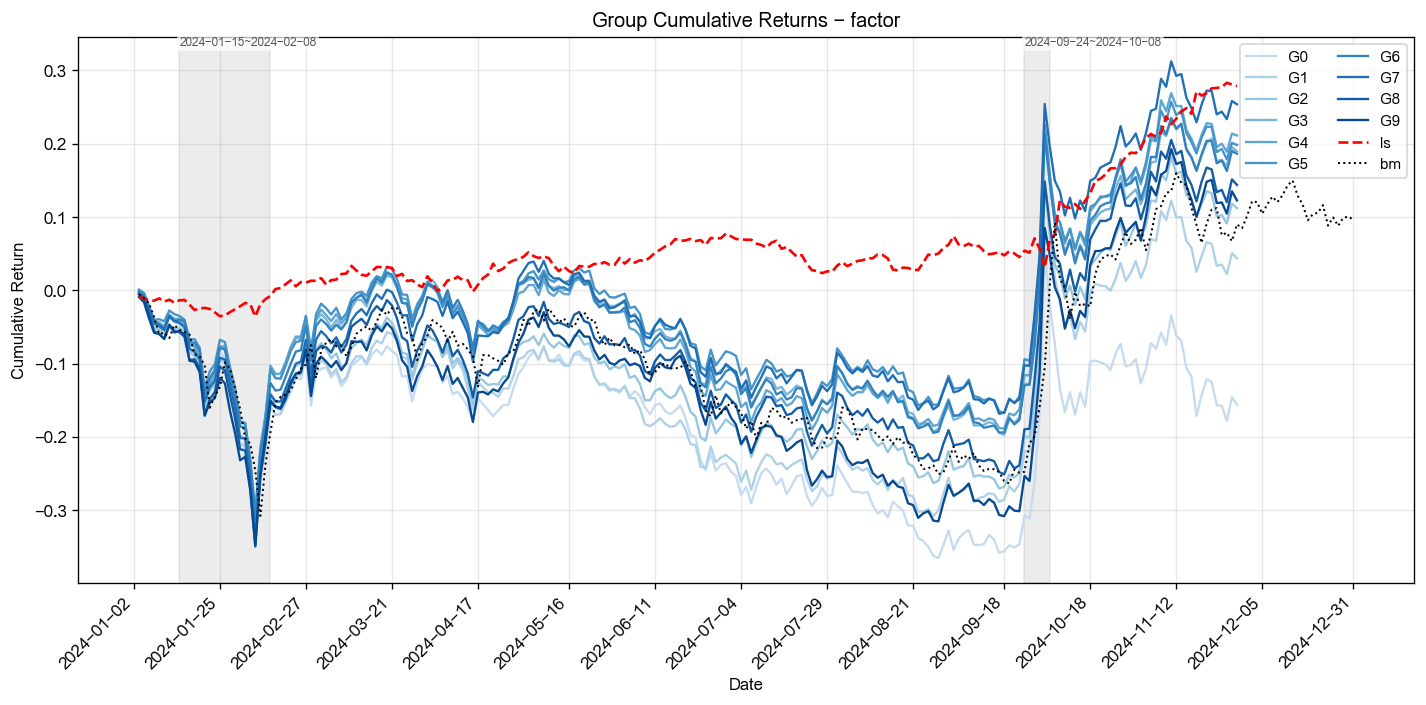
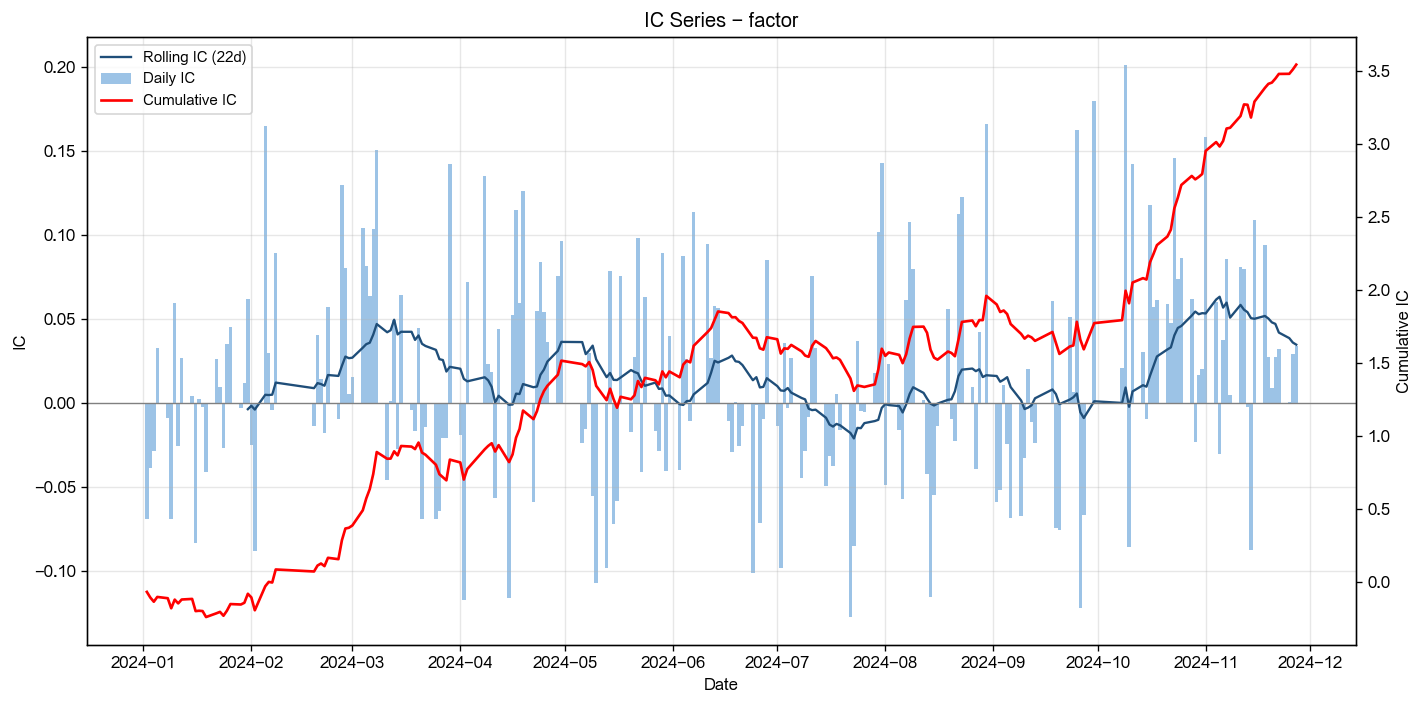
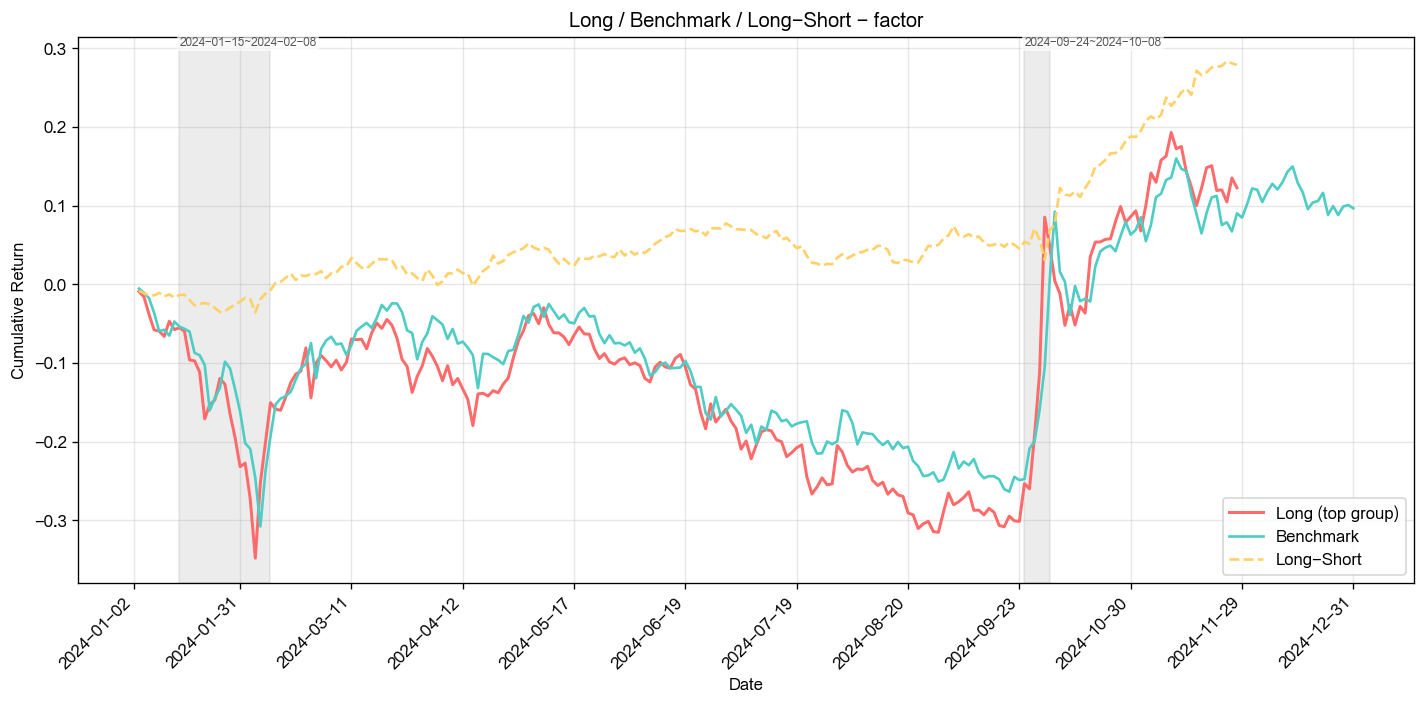
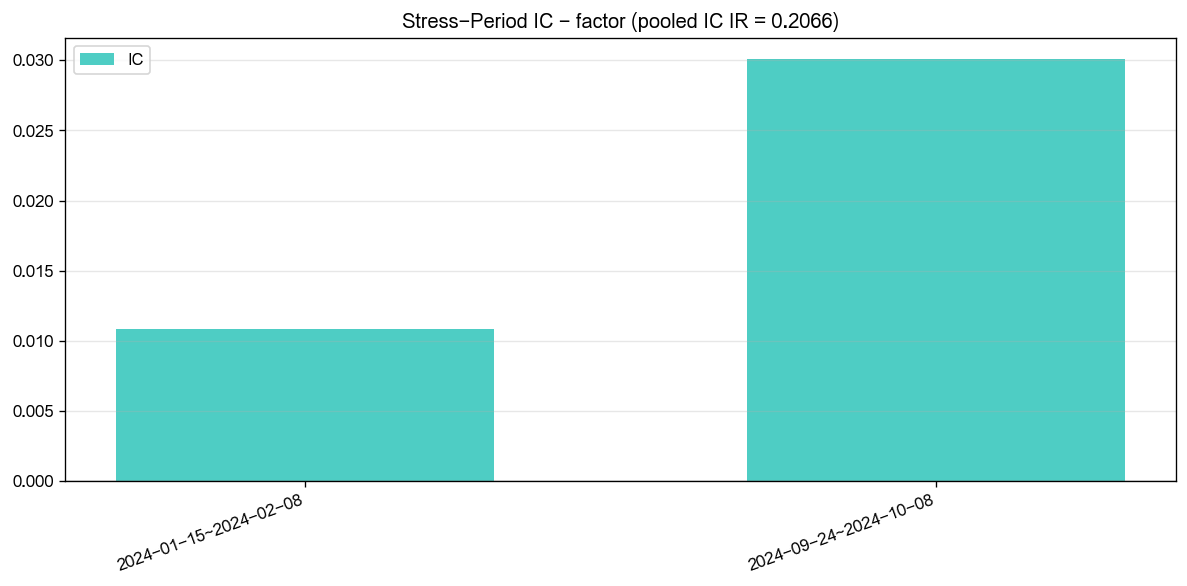
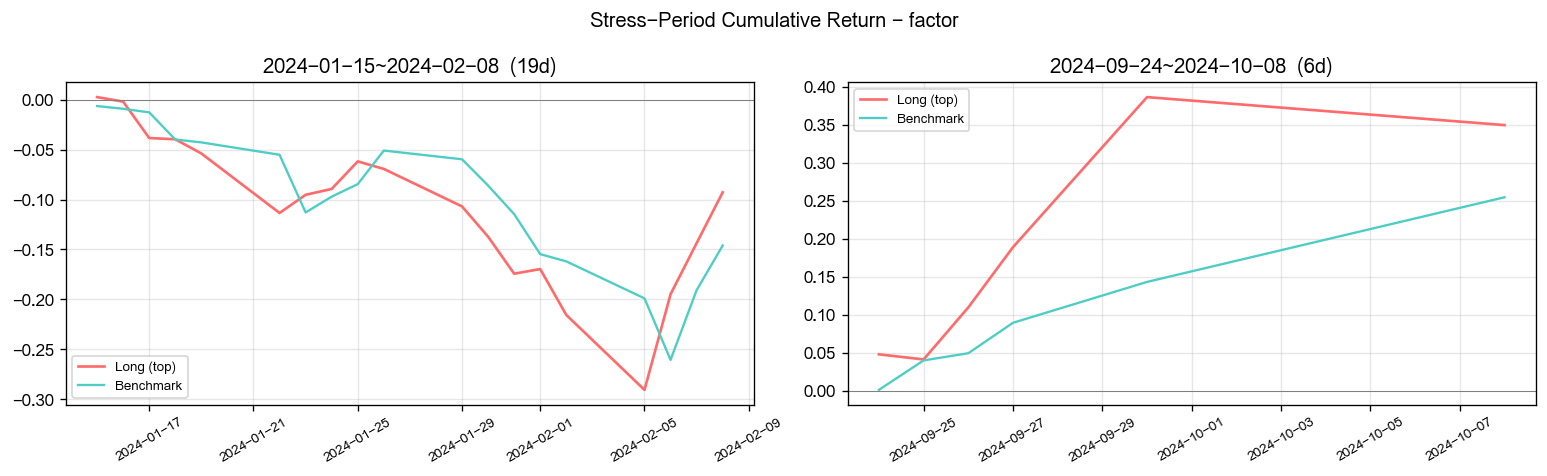

[2026-07-11 14:56:02] [info     ] ========== 因子池回归 ==========
[2026-07-11 14:56:02] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-11 14:56:02] [info     ] 获取收益率数据, 耗时: 0.7365 秒
[2026-07-11 14:56:03] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.1411 秒
[2026-07-11 14:56:03] [info     ] 统计 回归结果, 耗时: 0.0162 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9986,0.0440,0.0220,1.0000
2,amount,1.7152,0.0186,0.0108,1.0000
3,gross_profit_rate_ttm,1.5210,0.0069,0.0045,1.0000
4,netflow_amount_main,1.5043,0.0255,0.0169,1.0000
5,cci_14,1.4595,0.0348,0.0238,1.0000
6,net_profit_rate_ttm,1.4460,0.0040,0.0028,0.8000
7,bias_20,1.4421,0.0292,0.0202,0.9000
8,pb,1.4135,0.0097,0.0068,0.9000
9,netflow_amount_rate_main,1.4133,0.0093,0.0066,1.0000
10,pe_ttm,1.3093,0.0029,0.0022,0.9000

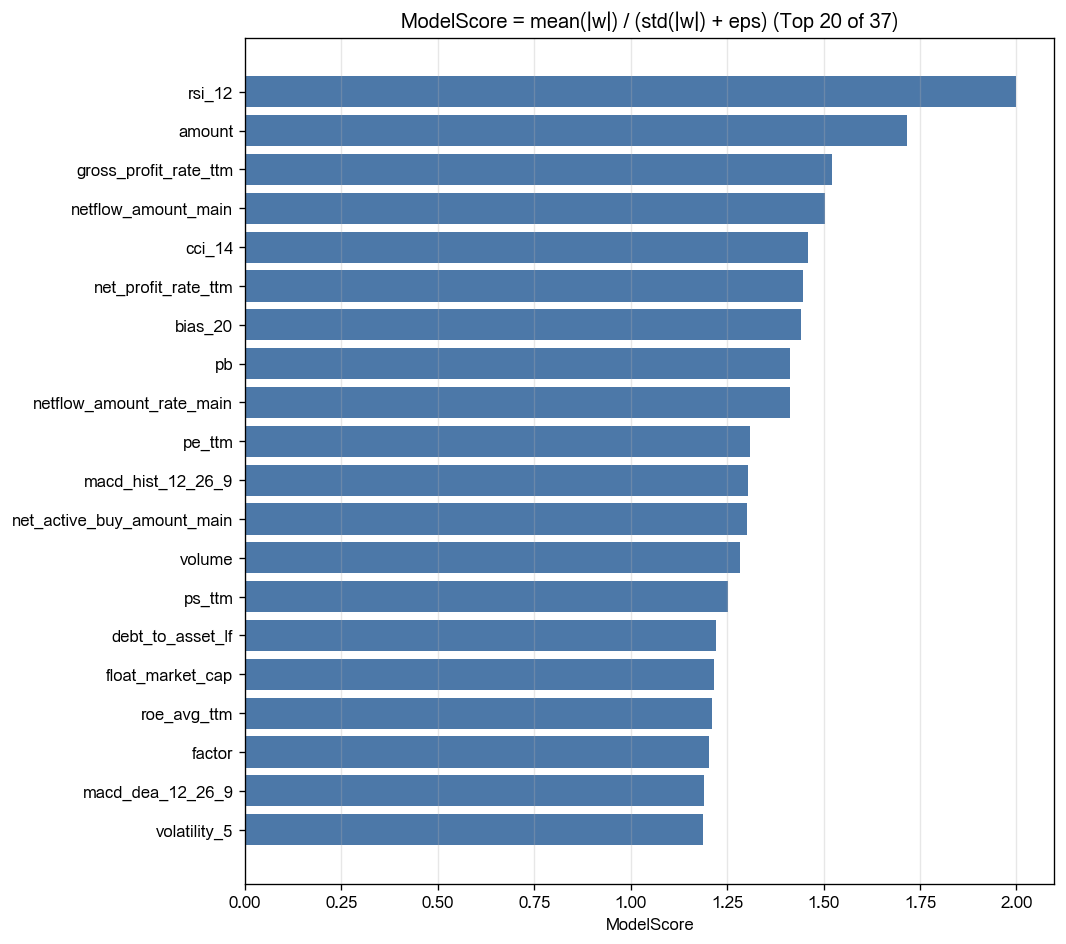
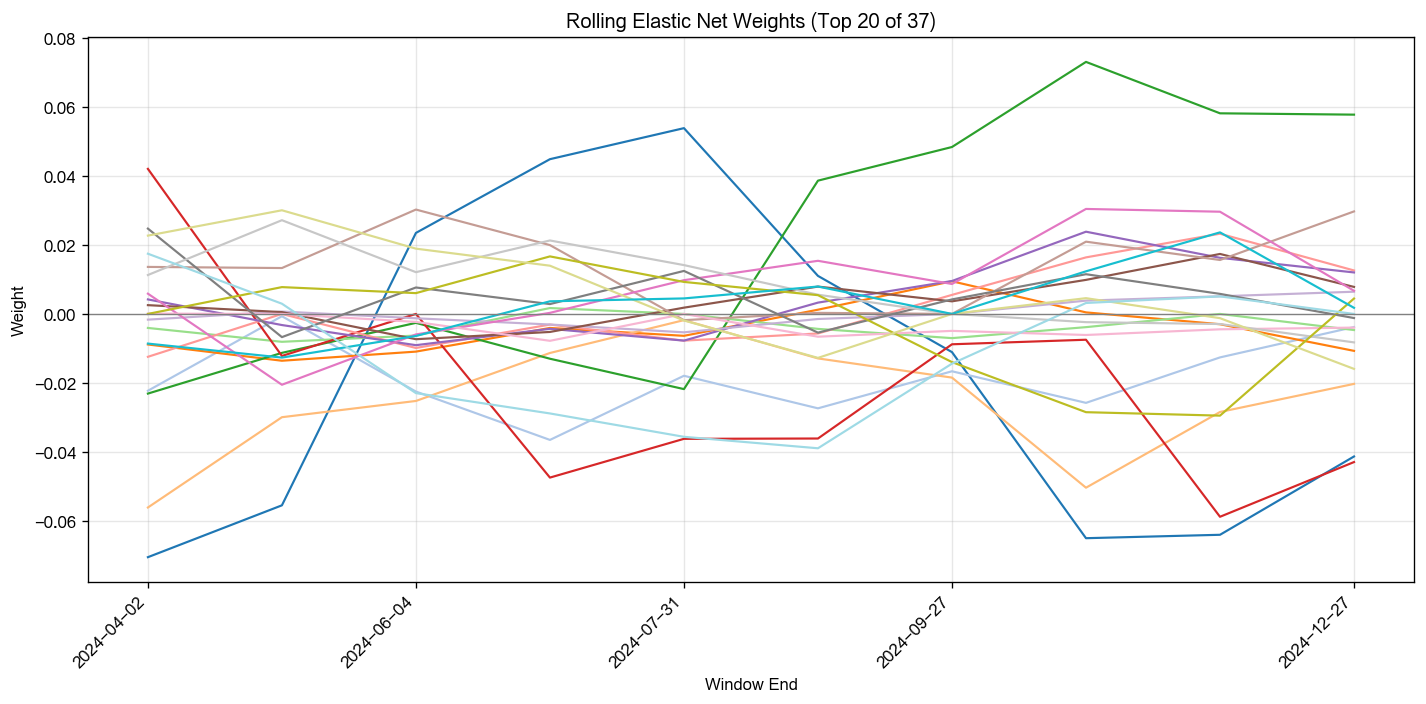
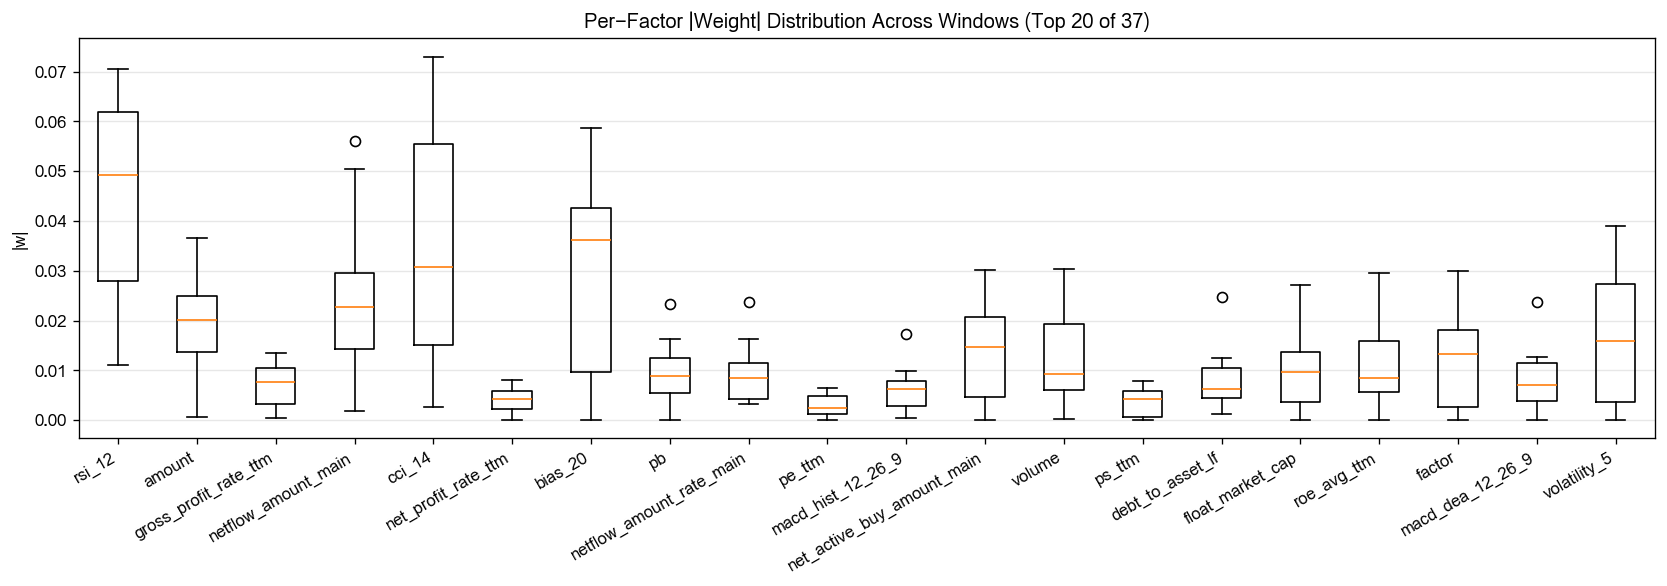
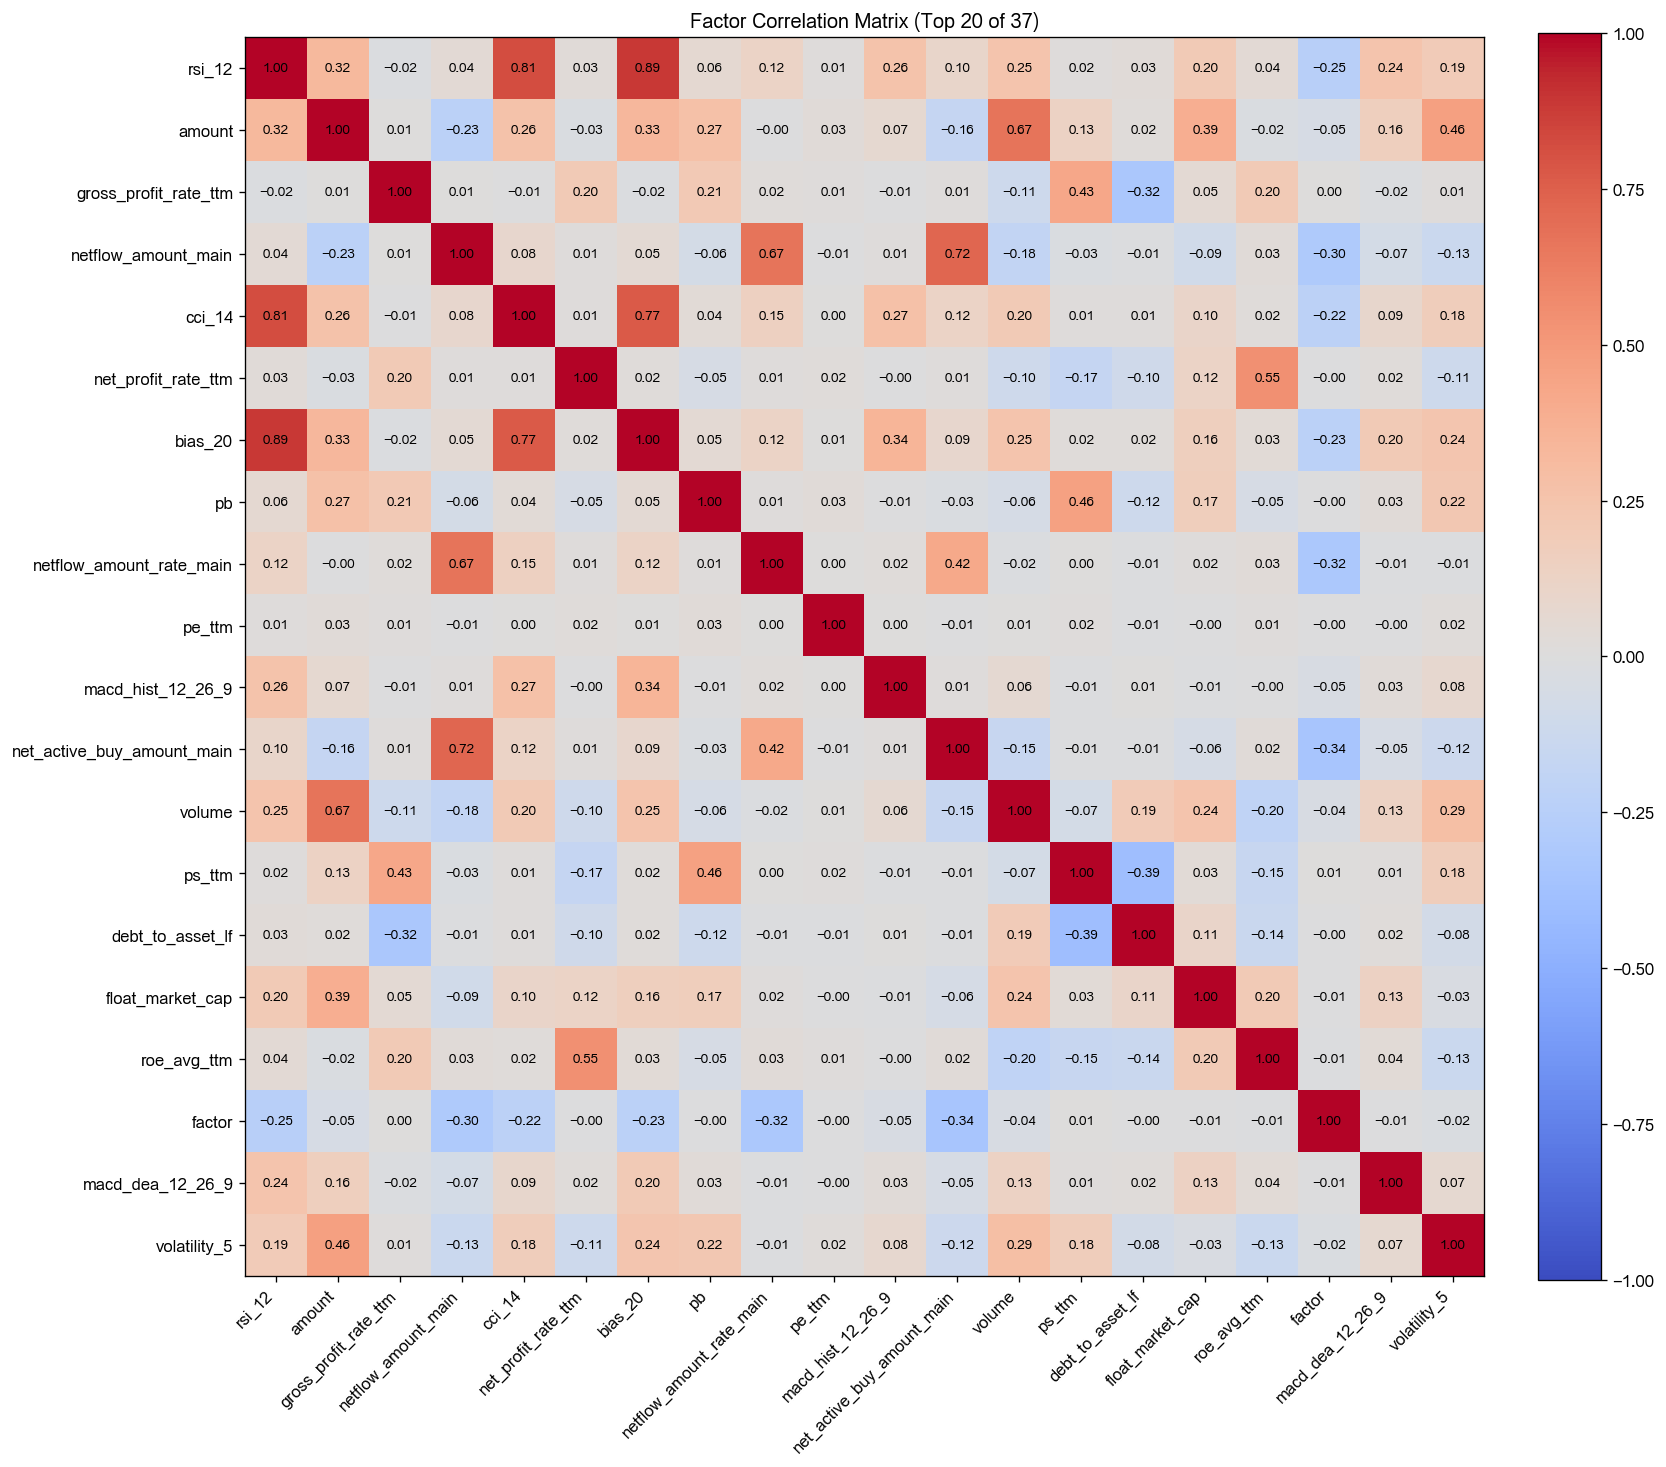

[2026-07-11 14:56:05] [warning  ] 返回的Outputs实例(size=35292140) 大于 64K, 将不会被缓存
[2026-07-11 14:56:05] [info     ] bigalpha_eval.v4 运行完成 [14.898s].


In [2]:
# 因子类别：量价 / 高频分钟 / 动量质量类
# 因子逻辑：上涨如果由多数分钟平滑推进，而不是少数分钟暴拉，趋势更健康。
# 因子公式：factor = day_ret * positive_minute_ratio / intraday_vol

def main(datasources, start_date, end_date):
    import pandas as pd
    import numpy as np
    import dai

    bar1m = datasources["bar1m"]

    sql = f"""
    WITH base AS (
        SELECT
            date, instrument, strftime(date, '%Y-%m-%d') AS trading_day,
            open, close,
            LAG(close, 1) OVER (PARTITION BY instrument, strftime(date, '%Y-%m-%d') ORDER BY date) AS prev_close
        FROM {bar1m}
        WHERE open > 0 AND close > 0
    ),
    minute_data AS (
        SELECT *, close / NULLIF(prev_close, 0) - 1 AS ret_1m
        FROM base
        WHERE prev_close > 0
    ),
    daily AS (
        SELECT
            trading_day, instrument,
            FIRST(open ORDER BY date) AS day_open,
            LAST(close ORDER BY date) AS day_close,
            AVG(CASE WHEN ret_1m > 0 THEN 1.0 ELSE 0.0 END) AS positive_ratio,
            STDDEV_SAMP(ret_1m) AS intraday_vol
        FROM minute_data
        WHERE ret_1m IS NOT NULL
        GROUP BY trading_day, instrument
    )
    SELECT
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        (day_close / NULLIF(day_open, 0) - 1)
        * positive_ratio
        / NULLIF(intraday_vol, 0) AS factor
    FROM daily
    WHERE CAST(trading_day AS DATETIME) BETWEEN CAST('{start_date}' AS DATETIME) AND CAST('{end_date}' AS DATETIME)
    """

    factor_df = dai.query(sql, filters={"date": [start_date, end_date]}, compression=True).df()
    stk_pool = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                         filters={"date": [start_date, end_date]}, compression=True).df()
    df = pd.merge(stk_pool, factor_df, how="left", on=["date", "instrument"])
    df["factor"] = df["factor"].replace([np.inf, -np.inf], np.nan)
    df["factor"] = df.groupby("date")["factor"].transform(lambda x: x.fillna(x.median()))
    df["factor"] = - df["factor"].fillna(0.0)
    return df[["date", "instrument", "factor"]]

if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )